# Cloud lifetime & size: 1D vs 3D (no_aerosols_zero_wind)

tobac feature-tracking on `qlqi_path.xy` (LWP > 1 g/m², min area 2500 m²),
4 reps × {2stream=1D, raytracer=3D}. Outputs from
`compute_cloud_lifetimes.py` under `analysis/lifetime/`.

Plots:
1. Per-track cloud lifetime through the day (1D vs 3D), 95% CI band
2. Birth-rate and mean-size ratio 3D/1D through the day
3. Size vs age for **morning-born** (LST 12–14) vs **afternoon-born** (LST 15–18)

_Pinned (not plotted here): the fewer-cells → more-fuel/cell catchment
argument — unclear how established it is in the shallow-Cu literature._

In [1]:
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from scipy.stats import t as student_t
from pathlib import Path
import seaborn as sns

LIFE  = Path('/pscratch/sd/m/mpowell/CASS_LES/analysis/lifetime/no_aerosols_zero_wind')
REPS  = [1, 2, 3, 4]
NREP  = len(REPS)
LST0  = 5.5                       # sim t=0 → 05:30 LST
RT    = {'2stream': '1D', 'raytracer': '3D'}
STY   = {'1D': dict(color='C0', ls='-'), '3D': dict(color='C1', ls='--')}

def ci95(std, n=NREP):
    """Half-width of the 95% CI on the ensemble mean (t-dist, n reps)."""
    return student_t.ppf(0.975, n - 1) * std / np.sqrt(n)

def load_features(rt):
    """Pooled per-feature table across reps (adds unique rep-scoped cell id)."""
    out = []
    for r in REPS:
        d = xr.open_dataset(LIFE / rt / f'rep_{r:02d}' / 'cloud_track_features.nc').to_dataframe()
        d['rep'] = r
        d['ucell'] = d['rep'] * 10**7 + d['cell']
        out.append(d)
    return pd.concat(out, ignore_index=True)

def load_life_ts(rt):
    """Per-frame lifetime: ensemble mean and std across reps (aligned on time)."""
    da = [xr.open_dataset(LIFE / rt / f'rep_{r:02d}' / 'cloud_lifetime_ts.nc')
          for r in REPS]
    n   = min(d.sizes['time'] for d in da)
    lst = da[0]['t_lst_h'].values[:n]
    arr = np.stack([d['lifetime_mean'].values[:n] for d in da]) / 60.0   # min
    for d in da:
        d.close()
    with np.errstate(invalid='ignore'), warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)   # pre-cloud frames all-NaN
        return lst, np.nanmean(arr, 0), np.nanstd(arr, 0, ddof=1)

F = {tag: load_features(rt) for rt, tag in RT.items()}
print({k: f'{len(v):,} features' for k, v in F.items()})

{'1D': '672,836 features', '3D': '572,276 features'}


## 1. Per-track cloud lifetime through the day


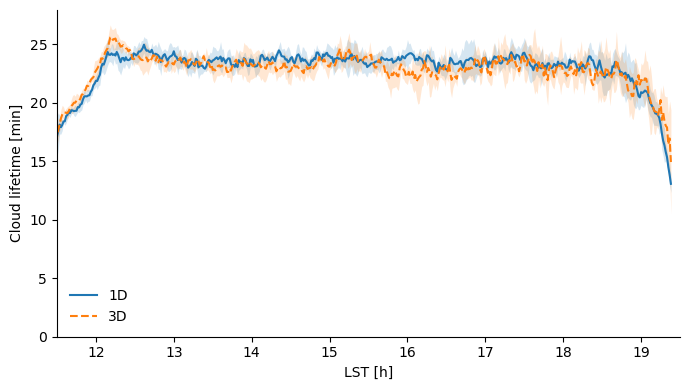

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
for rt, tag in RT.items():
    lst, m, s = load_life_ts(rt)
    ax.plot(lst, m, label=tag, **STY[tag])
    ax.fill_between(lst, m - s, m + s, color=STY[tag]['color'], alpha=0.18, lw=0)
ax.set_xlim(11.5, 19.5)
ax.set_xlabel('LST [h]')
ax.set_ylabel('Cloud lifetime [min]')

ax.legend(frameon=False)
sns.despine()
fig.tight_layout()


## 2. Birth rate and mean size — ratio 3D / 1D through the day

Births = first detection of each track (`age_s == 0`); size = mean `L_m`
of all active features. Both per 30-min LST bin, pooled over reps.
Births < 1 ⇒ 3D suppresses genesis; size > 1 ⇒ 3D clouds larger.

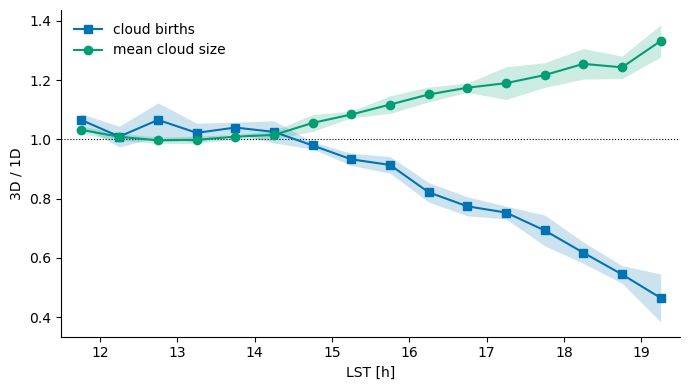

In [10]:
bins = np.arange(11.5, 19.6, 0.5)
ctr  = 0.5 * (bins[:-1] + bins[1:])

def births_per_bin(df):
    b = df[df['age_s'] == 0].copy()
    b['lst'] = b['t_sim_s'] / 3600.0 + LST0
    h, _ = np.histogram(b['lst'], bins=bins)
    return h.astype(float)

def meanL_per_bin(df):
    g = df.copy()
    g['lst'] = g['t_sim_s'] / 3600.0 + LST0
    g['bin'] = pd.cut(g['lst'], bins=bins, labels=ctr)
    return g.groupby('bin', observed=True)['L_m'].mean().reindex(ctr).values

def _ratio_per_rep(kind):
    """Per-rep 3D/1D ratio (paired by rep); returns (n_bin, n_rep)."""
    cols = []
    for r in REPS:
        f1 = F['1D'][F['1D']['rep'] == r]
        f3 = F['3D'][F['3D']['rep'] == r]
        if kind == 'births':
            n1, n3 = births_per_bin(f1), births_per_bin(f3)
            cols.append(np.where(n1 > 0, n3 / n1, np.nan))
        else:
            cols.append(meanL_per_bin(f3) / meanL_per_bin(f1))
    return np.array(cols).T

fig, ax = plt.subplots(figsize=(7, 4))
ax.axhline(1.0, color='k', lw=0.8, ls=':')
cb = sns.color_palette("colorblind")          # colorblind-safe
for kind, mk, c, lbl in [('births', 's', cb[0], 'cloud births'),
                         ('size',   'o', cb[2], 'mean cloud size')]:
    a = _ratio_per_rep(kind)
    m, s = np.nanmean(a, 1), np.nanstd(a, 1, ddof=1)
    ax.plot(ctr, m, marker=mk, color=c, label=lbl)
    ax.fill_between(ctr, m - s, m + s, color=c, alpha=0.2, lw=0)

ax.set_xlim(11.5, 19.5)
ax.set_xlabel('LST [h]')
ax.set_ylabel('3D / 1D')

ax.legend(frameon=False)
sns.despine()
fig.tight_layout()


## 3. Size vs age — morning-born vs afternoon-born

Cohorts by **birth LST**. Morning (12–14): sun high, shadows ~under clouds.
Afternoon (15–18): sun low, shadows displaced & elongated.
Tests “1D ≡ 3D in the morning; 3D born bigger **and** grows faster in the afternoon”.

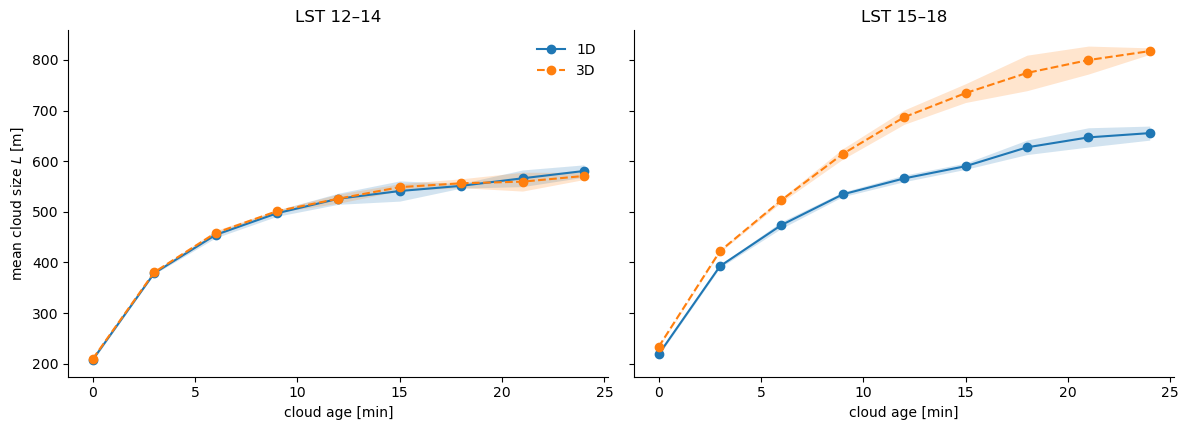

In [9]:
AGES = np.array([0, 3, 6, 9, 12, 15, 18, 21, 24]) * 60.0   # s

def size_vs_age(df, lo, hi):
    """Per-rep mean L(age) for birth cohort [lo,hi); returns (n_age, n_rep)."""
    bt = df[df['age_s'] == 0][['ucell', 't_sim_s']].rename(columns={'t_sim_s': 'bt'})
    d  = df.merge(bt, on='ucell', how='left')
    d['blst'] = d['bt'] / 3600.0 + LST0
    d = d[(d['blst'] >= lo) & (d['blst'] < hi)]
    cols = []
    for r in sorted(d['rep'].unique()):
        dr = d[d['rep'] == r]
        col = [dr.loc[np.isclose(dr['age_s'], a), 'L_m'].mean()
               if (np.isclose(dr['age_s'], a)).sum() > 30 else np.nan
               for a in AGES]
        cols.append(col)
    return np.array(cols).T

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), sharey=True)
for ax, (lo, hi, title) in zip(
        axes,
        [(12, 14, 'LST 12–14'),
         (15, 18, 'LST 15–18')]):
    for rt, tag in RT.items():
        a = size_vs_age(F[tag], lo, hi)
        m, s = np.nanmean(a, 1), np.nanstd(a, 1, ddof=1)
        ax.plot(AGES / 60.0, m, marker='o', label=tag, **STY[tag])
        ax.fill_between(AGES / 60.0, m - s, m + s,
                        color=STY[tag]['color'], alpha=0.2, lw=0)
    ax.set_xlabel('cloud age [min]')
    ax.set_title(title)

axes[0].set_ylabel('mean cloud size $L$ [m]')
axes[0].legend(frameon=False)
sns.despine()
fig.tight_layout()


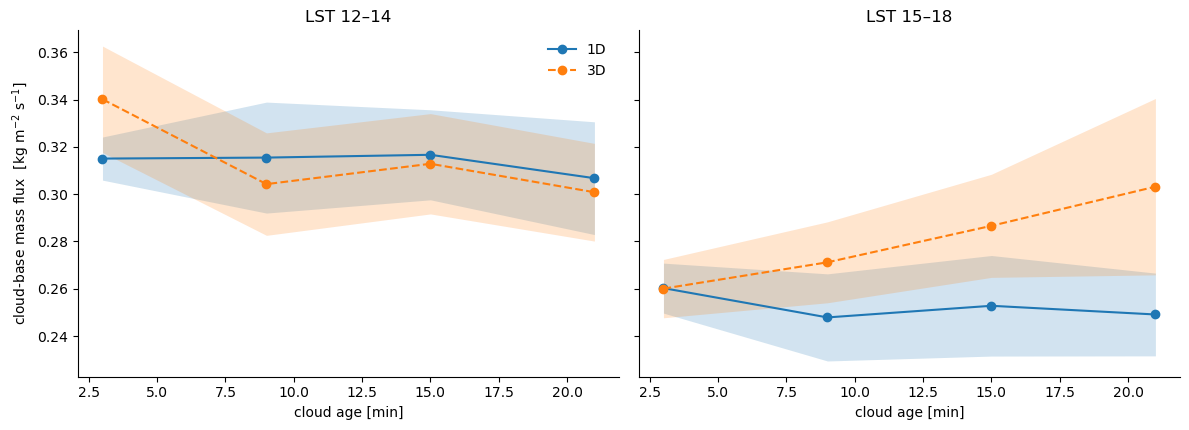

In [8]:
_MF = Path('/pscratch/sd/m/mpowell/CASS_LES/analysis/cloudbase_mf/no_aerosols_zero_wind')
AGE_EDGES = np.array([0, 6, 12, 18, 24]) * 60.0          # 4 bins (min)
AGE_CTR   = (AGE_EDGES[:-1] + AGE_EDGES[1:]) / 2 / 60.0   # 3, 9, 15, 21 min

def _mf_curve(rt, lo, hi):
    """Per-rep binned mean M(age) for birth cohort [lo,hi); returns (n_bin, n_rep)."""
    cols = []
    for r in REPS:
        d = xr.open_dataset(_MF / rt / f'rep_{r:02d}' / 'cb_mf.nc').to_dataframe()
        d = d[(d['blst'] >= lo) & (d['blst'] < hi)]
        b = pd.cut(d['age_s'], AGE_EDGES, labels=False)
        m = d.groupby(b)['M'].mean().reindex(range(len(AGE_CTR)))
        cols.append(m.values)
    return np.array(cols).T

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), sharey=True)
for ax, (lo, hi, title) in zip(axes,
        [(12, 14, 'LST 12–14'), (15, 18, 'LST 15–18')]):
    for rt, tag in RT.items():
        a = _mf_curve(rt, lo, hi)
        m, s = np.nanmean(a, 1), np.nanstd(a, 1, ddof=1)
        ax.plot(AGE_CTR, m, marker='o', label=tag, **STY[tag])
        ax.fill_between(AGE_CTR, m - s, m + s,
                        color=STY[tag]['color'], alpha=0.2, lw=0)
    ax.set_xlabel('cloud age [min]')
    ax.set_title(title)
axes[0].set_ylabel(r'cloud-base mass flux  [kg m$^{-2}$ s$^{-1}$]')
axes[0].legend(frameon=False)
sns.despine()
fig.tight_layout()


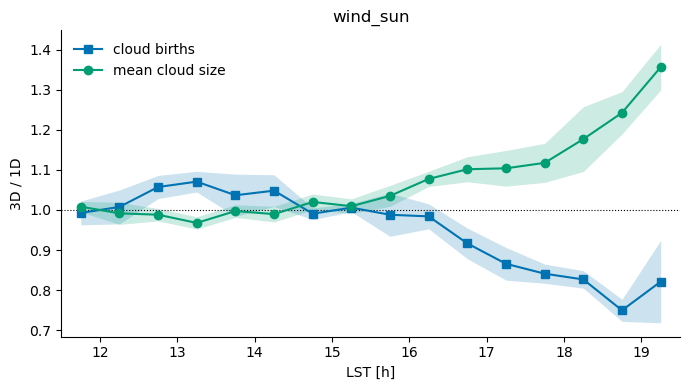

In [14]:
# wind_sun — births & size ratio 3D/1D (4 reps, paired, ±1 rep-std)
_WS = Path('/pscratch/sd/m/mpowell/CASS_LES/analysis/lifetime/wind_sun')

def _ws_rep(rt, r):
    d = xr.open_dataset(_WS / rt / f'rep_{r:02d}' / 'cloud_track_features.nc').to_dataframe()
    d['ucell'] = d['cell']
    return d

def _ws_ratio_per_rep(kind):
    """Per-rep 3D/1D ratio (paired by rep); returns (n_bin, n_rep)."""
    cols = []
    for r in REPS:
        f1, f3 = _ws_rep('2stream', r), _ws_rep('raytracer', r)
        if kind == 'births':
            n1, n3 = births_per_bin(f1), births_per_bin(f3)
            cols.append(np.where(n1 > 0, n3 / n1, np.nan))
        else:
            cols.append(meanL_per_bin(f3) / meanL_per_bin(f1))
    return np.array(cols).T

fig, ax = plt.subplots(figsize=(7, 4))
ax.axhline(1.0, color='k', lw=0.8, ls=':')
cb = sns.color_palette("colorblind")
for kind, mk, c, lbl in [('births', 's', cb[0], 'cloud births'),
                         ('size',   'o', cb[2], 'mean cloud size')]:
    a = _ws_ratio_per_rep(kind)
    m, s = np.nanmean(a, 1), np.nanstd(a, 1, ddof=1)
    ax.plot(ctr, m, marker=mk, color=c, label=lbl)
    ax.fill_between(ctr, m - s, m + s, color=c, alpha=0.2, lw=0)

ax.set_xlim(11.5, 19.5)
ax.set_xlabel('LST [h]')
ax.set_ylabel('3D / 1D')
ax.set_title('wind_sun')
ax.legend(frameon=False)
sns.despine()
fig.tight_layout()


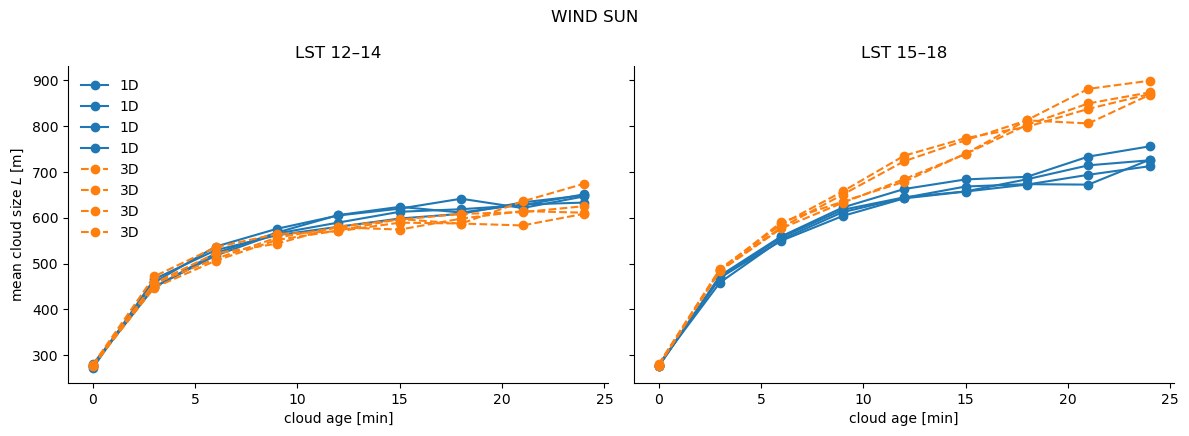

In [15]:
## 4. wind_sun — size vs age (shadow-tracking wind)
_WS = Path('/pscratch/sd/m/mpowell/CASS_LES/analysis/lifetime/wind_sun')

def _load_ws(rt):
    out = []
    for r in REPS:
        d = xr.open_dataset(_WS / rt / f'rep_{r:02d}'
                            / 'cloud_track_features.nc').to_dataframe()
        d['rep'] = r
        d['ucell'] = d['rep'] * 10**7 + d['cell']
        out.append(d)
    return pd.concat(out, ignore_index=True)

FWS = {tag: _load_ws(rt) for rt, tag in RT.items()}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), sharey=True)
for ax, (lo, hi, title) in zip(axes,
        [(12, 14, 'LST 12–14'), (15, 18, 'LST 15–18')]):
    for rt, tag in RT.items():
        y = size_vs_age(FWS[tag], lo, hi)
        ax.plot(AGES / 60.0, y, marker='o', label=tag, **STY[tag])
    ax.set_xlabel('cloud age [min]')
    ax.set_title(title)
axes[0].set_ylabel('mean cloud size $L$ [m]')
axes[0].legend(frameon=False)
plt.suptitle("WIND SUN")
sns.despine()
fig.tight_layout()